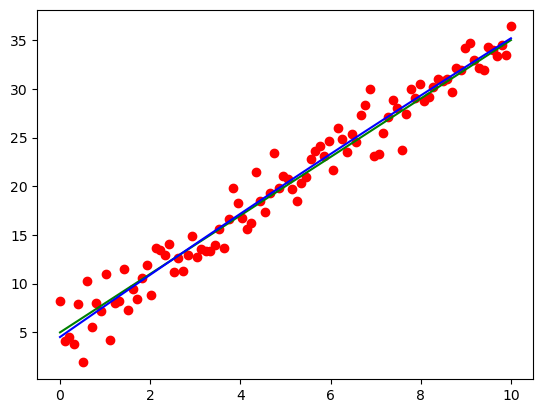

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import math

#numpy vs scipy

np.random.seed(1)
x=np.linspace(0,10,100)
y_true= 3*x + 5
y=y_true + np.random.normal(scale=2, size=len(x))


#NUMPY
#FITT CON NuMPY e regressione lineare
coeffs = np.polyfit(x, y, deg=1)
a, b = coeffs  # a = coefficiente angolare, b = intercetta

# Predizioni
y_pred = a * x + b

# FITT CON NuMPY e regressione polinomiale

fit=np.polyfit(x,y,deg=2) 
poly=np.poly1d(fit)


y_pred_np = poly(x)




#CALCOLO MATRICI RMSE E MAE

mae= np.mean(np.abs(y-y_pred_np)) 
rmse=np.sqrt(np.mean((y-y_pred_np)**2))

#SCIPY
#fitting e regressione lineare CON SCIPY

def lineare(x,a,b):
    return a * x +b

paramsl, _= sp.optimize.curve_fit(lineare,x,y)

a,b = paramsl

y_pred_sc=lineare(x,a,b)

#regressione polinomale

def modello_polinomiale(x, a, b, c):
    return a * x**2 + b * x + c
paramsp, _ = sp.optimize.curve_fit(modello_polinomiale, x, y)
a, b, c = paramsp
y_pred = modello_polinomiale(x, a, b, c)

#calcolo metrice rmese e mae con numpy

mae= np.mean(np.abs(y-y_pred_sc)) 
rmse=np.sqrt(np.mean((y-y_pred_sc)**2))

#plot

plt.figure()
plt.plot(x,y_true, label="Dati reali", color="green")
plt.scatter(x,y, label="Dati con errori", color="red")
plt.plot(x,y_pred, label="Dati fittati", color="blue")
plt.show()




In [23]:
#SCIKIT-LEARN

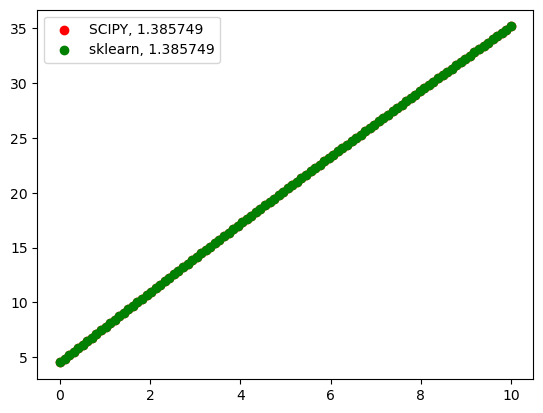

In [26]:
#regressione lineare
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,root_mean_squared_error

model_lineare=LinearRegression()
model_lineare.fit(x.reshape(-1,1),y) # se prendo da database sennò devo fare al posto della x mettre x.reshape(-1,1)
y_pred_linear=model_lineare.predict(x.reshape(-1,1)) #ideam qua

#regressione polinomiale

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Regressione polinomiale grado 2
model_poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_poly2.fit(x.reshape(-1,1), y)
y_pred_poly2 = model_poly2.predict(x.reshape(-1,1))

#rmse e mae

rmse_linear = root_mean_squared_error(y, y_pred_linear)
mae_linear = mean_absolute_error(y, y_pred_linear)

plt.figure()

plt.scatter(x,y_pred, label=f"SCIPY, {mae:2f}", color="red")
plt.scatter(x,y_pred_poly2, label=f"sklearn, {mae_linear:2f}", color="green")
plt.legend()
plt.show()



